### Intro to BioPython

In [7]:
# Install BioPython
!pip install biopython


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
from Bio.Seq import Seq

# Create a BioPython sequence object
my_dna = Seq("ATGGCCCTGTGGATGCGCCTC")
print(f"DNA Sequence: {my_dna}")

DNA Sequence: ATGGCCCTGTGGATGCGCCTC


In [9]:
# Transcription
my_rna = my_dna.transcribe()
print(f"RNA: {my_rna}")

# Translation
my_protein = my_dna.translate()
print(f"Protein: {my_protein}")

# Reverse Complement
my_rev_comp = my_dna.reverse_complement()
print(f"Reverse Complement: {my_rev_comp}")

RNA: AUGGCCCUGUGGAUGCGCCUC
Protein: MALWMRL
Reverse Complement: GAGGCGCATCCACAGGGCCAT


In [10]:
# Translating a longer sequence with a stop codon
long_dna = Seq("ATGGCCCTGTGGATGCGCCTCCTGUAA")
print(long_dna.translate())

MALWMRLL*


In [11]:
from Bio import SeqIO

# Parsing a FASTA file in one loop
for record in SeqIO.parse("genes.fasta", "fasta"):
    print(f"ID: {record.id}")
    print(f"Sequence: {record.seq[:20]}...") # Show first 20 bases
    print(f"Length: {len(record)}")

ID: gene_A_human
Sequence: ATGACTGAATATAAACTTGT...
Length: 120
ID: gene_B_mouse
Sequence: ATGGAGGATTCGCAGTCGAT...
Length: 119
ID: gene_C_fly
Sequence: ATGAATTCGATCGGATCGCC...
Length: 115


### Sequence Alignment

Global Alignment

In [ ]:
from Bio import Align

# Define two similar sequences
seq1 = "GATTACA"
seq2 = "GCATAC"

# Create an aligner object
aligner = Align.PairwiseAligner()

# Perform Global Alignment (default)
alignments = aligner.align(seq1, seq2)

# Look at the first alignment result
best_alignment = alignments[0]
print(best_alignment)
print(f"Global Alignment Score: {best_alignment.score}")

target            0 GATTACA 7
                  0 |..|||- 7
query             0 GCATAC- 6

Global Alignment Score: 3.0


Local Alignment

In [ ]:
# Create a local alignment scenario
long_seq = "ACGTCGATCGGCTAGCTAGCTAGCTAG"
short_seq = "GCTAGCTAG"

# Set mode to local
aligner.mode = 'local'

local_alignments = aligner.align(long_seq, short_seq)
best_local = local_alignments[0]

print(best_local)
print(f"Local Alignment Score: {best_local.score}")

target           10 GCTAGCTAG 19
                  0 |||||||||  9
query             0 GCTAGCTAG  9

Local Alignment Score: 9.0


Customize the Scoring

In [ ]:
# Customizing penalties
aligner.match_score = 2
aligner.mismatch_score = -1
aligner.open_gap_score = -0.5

# Re-run the alignment
custom_alignments = aligner.align(seq1, seq2)
print(custom_alignments[0])

target            0 G-ATTAC 6
                  0 |-|-||| 7
query             0 GCA-TAC 6



### Visualizing GC Content with Matplotlib

In [ ]:
# Install matplotlib if you haven't already
pip install matplotlib

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 3.4 MB/s eta 0:00:03
   -- ------------------------------------- 0.5/8.1 MB 3.4 MB/s eta 0:00:03
   ----- ---------------------------------- 1.0/8.1 MB 1.9 MB/s eta 0:00:04
   ----- ---------------------------------- 1.0/8.1 MB 1.9 MB/s eta 0:00:04
   ------ --------------------------------- 1.3/8.1 MB 1.3 MB/s eta 0:00:06
   ------- -------------------------------- 1.6/8.1 MB 1.2 MB/s eta 0:00:06
   --------- ------------------------------ 1.8/8.1 MB 1.4 MB/s eta 0:00:05
   ----------- ---------------------------- 2.4/8.1 MB 1.4 MB/s eta 0:00:05
   ----------- ---------------------------- 2.4/8.1 MB 1.4 MB/s eta 0:00:05
   ------------ --------------------------- 2.6/8.1 MB 1.3 MB/s eta 0:00:05
   -------------- ------------------------- 2.9/8.1 MB 1.3 MB/s eta 0:00:05
   --------------- ------------------------ 3.1/8.1 MB 1.3 MB/s eta 0:00:04
   ----------------


[notice] A new release of pip is available: 25.2 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import matplotlib.pyplot as plt
from Bio import SeqIO
from Bio.SeqUtils import gc_fraction

In [ ]:
# 1. Load our sequence
record = SeqIO.read("my_sequence.fasta", "fasta")
sequence = record.seq

# 2. Define window size
window_size = 100
gc_values = []

# 3. Slide the window across the sequence
for i in range(len(sequence) - window_size + 1):
    sub_seq = sequence[i : i + window_size]
    # Calculate GC fraction (0.0 to 1.0) and convert to percentage
    gc_val = gc_fraction(sub_seq) * 100
    gc_values.append(gc_val)

print(f"Calculated {len(gc_values)} GC data points!")

Calculated 35 GC data points!


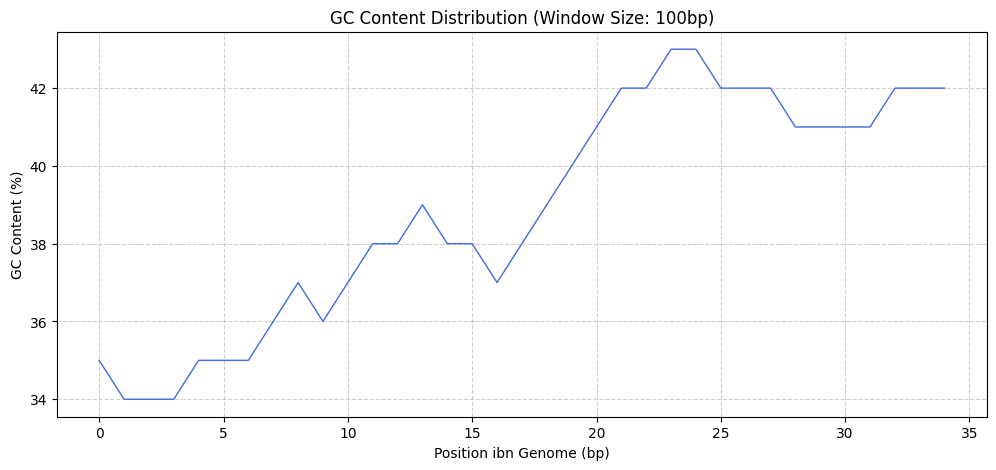

In [ ]:
# 4. Create the plot
plt.figure(figsize=(12, 5))
plt.plot(gc_values, color='royalblue', linewidth=1)

# 5. Add labels and styling
plt.title(f"GC Content Distribution (Window Size: {window_size}bp)")
plt.xlabel("Position in Genome (bp)")
plt.ylabel("GC Content (%)")
plt.grid(True, linestyle='--', alpha=0.6)

# Display the plot
plt.show()